# 06: Causal Contrasts and Overlap

**Objective**: Handle causal contrasts/estimands, including exchangeability, positivity, and competing events

## Learning Goals
1. Understand target trial requirements for identifiable contrasts
2. Recognize EHR data constraints (unmeasured confounding, structural non-overlap)
3. Diagnose overlap violations and competing event issues
4. Apply mitigation strategies (with their limitations)
5. Make explicit estimand statements and apply decision rules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

/Users/yanfeiwang/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 1. Target Trial Requirements

### Identifiability Conditions

For a causal contrast to be identifiable from observational data:

1. **Exchangeability**: $Y^{a} \perp A \mid X$ (no unmeasured confounding)
2. **Positivity**: $0 < P(A=a|X=x) < 1$ for all $x$ in support of $X$
3. **Consistency**: $Y = Y^a$ when $A = a$

**In EHR data**: These assumptions are often violated due to:
- Unmeasured confounding (disease severity, social determinants, physician preferences)
- Structural non-overlap (contraindications, standard-of-care patterns)
- Competing events that alter risk sets and estimands

## 2. Simulate EHR Data with Structural Non-Overlap

We'll create a realistic scenario where:
- Treatment B is contraindicated for high-risk patients (structural non-overlap)
- Unmeasured severity affects both treatment and outcome
- Competing events (death) occur differentially by treatment

In [3]:
def simulate_ehr_data_with_overlap_issues(n=5000, seed=42):
    """
    Simulate EHR data with structural non-overlap and competing events.
    
    Scenario: Two treatments (A, B) for a chronic condition
    - Treatment B is contraindicated for high-risk patients
    - Unmeasured severity affects treatment selection and outcomes
    - Competing event: death before outcome assessment
    """
    np.random.seed(seed)
    
    # Measured covariates
    age = np.random.normal(65, 12, n)
    age = np.clip(age, 18, 95)
    
    comorbidity_count = np.random.poisson(2, n)
    comorbidity_count = np.clip(comorbidity_count, 0, 8)
    
    prior_hospitalization = np.random.binomial(1, 0.3, n)
    
    # Lab values (standardized)
    creatinine = np.random.gamma(2, 0.5, n)  # Higher = worse kidney function
    hemoglobin = np.random.normal(13, 2, n)  # Lower = worse
    
    # UNMEASURED CONFOUNDER: True disease severity (not in data)
    # Correlated with measured variables but adds independent information
    unmeasured_severity = (
        0.3 * (age - 65) / 12 + 
        0.4 * comorbidity_count / 4 + 
        0.2 * prior_hospitalization +
        0.3 * creatinine / 2 +
        np.random.normal(0, 1, n)  # Additional unmeasured component
    )
    
    # Create risk score from measured variables (proxy for severity)
    risk_score = (
        0.02 * (age - 65) + 
        0.3 * comorbidity_count + 
        0.5 * prior_hospitalization +
        0.3 * creatinine +
        -0.2 * hemoglobin
    )
    risk_score_std = (risk_score - risk_score.mean()) / risk_score.std()
    
    # STRUCTURAL NON-OVERLAP: Treatment B contraindicated for high-risk patients
    # High risk defined as top quartile of risk score OR very high severity
    contraindication = (risk_score_std > np.percentile(risk_score_std, 75)) | \
                       (unmeasured_severity > np.percentile(unmeasured_severity, 85))
    
    # Treatment assignment (A=0, B=1)
    # Pr(B) depends on covariates but drops to near-zero for contraindicated patients
    logit_treatment = (
        -0.5 +
        -0.3 * risk_score_std +  # Lower risk → more likely B
        -0.2 * (age - 65) / 12 +
        -5.0 * contraindication +  # Strong contraindication effect
        0.1 * np.random.normal(0, 1, n)  # Physician preference noise
    )
    
    prob_treatment_b = 1 / (1 + np.exp(-logit_treatment))
    treatment = np.random.binomial(1, prob_treatment_b)
    
    # True treatment effect (heterogeneous)
    # Treatment B reduces risk on average, but effect varies by severity
    treatment_effect = -0.15 + 0.05 * unmeasured_severity  # Less effective for sicker patients
    
    # COMPETING EVENT: Death before outcome (12-month mortality)
    logit_death = (
        -3.0 +
        0.5 * unmeasured_severity +
        0.3 * risk_score_std +
        0.2 * treatment +  # Treatment B slightly higher mortality (sicker patients who can tolerate it)
        0.05 * (age - 65) / 12
    )
    prob_death = 1 / (1 + np.exp(-logit_death))
    death = np.random.binomial(1, prob_death)
    
    # Primary outcome: Hospitalization (only observable if alive)
    # True causal model
    logit_outcome = (
        -1.5 +
        0.6 * unmeasured_severity +
        0.4 * risk_score_std +
        treatment_effect * treatment +  # Causal effect
        0.03 * (age - 65) / 12
    )
    
    prob_outcome = 1 / (1 + np.exp(-logit_outcome))
    hospitalization = np.random.binomial(1, prob_outcome)
    
    # Observed outcome (missing if dead)
    hospitalization_observed = hospitalization.astype(float)  # Convert to float to allow NaN
    hospitalization_observed[death == 1] = np.nan
    
    # Create DataFrame
    df = pd.DataFrame({
        'age': age,
        'comorbidity_count': comorbidity_count,
        'prior_hospitalization': prior_hospitalization,
        'creatinine': creatinine,
        'hemoglobin': hemoglobin,
        'risk_score': risk_score_std,
        'contraindication': contraindication.astype(int),
        'treatment': treatment,  # 0=A, 1=B
        'death': death,
        'hospitalization': hospitalization_observed,
        # Hidden variables (not available in real EHR)
        'unmeasured_severity': unmeasured_severity,
        'true_treatment_effect': treatment_effect
    })
    
    return df

# Generate data
df = simulate_ehr_data_with_overlap_issues(n=5000)

print("Data Summary:")
print(f"Total N: {len(df)}")
print(f"Treatment A: {(df['treatment']==0).sum()} ({(df['treatment']==0).mean()*100:.1f}%)")
print(f"Treatment B: {(df['treatment']==1).sum()} ({(df['treatment']==1).mean()*100:.1f}%)")
print(f"\nContraindication prevalence: {df['contraindication'].mean()*100:.1f}%")
print(f"Treatment B among contraindicated: {df[df['contraindication']==1]['treatment'].mean()*100:.1f}%")
print(f"Treatment B among non-contraindicated: {df[df['contraindication']==0]['treatment'].mean()*100:.1f}%")
print(f"\nCompeting event (death): {df['death'].mean()*100:.1f}%")
print(f"Death rate - Treatment A: {df[df['treatment']==0]['death'].mean()*100:.1f}%")
print(f"Death rate - Treatment B: {df[df['treatment']==1]['death'].mean()*100:.1f}%")
print(f"\nMissing outcomes due to death: {df['hospitalization'].isna().sum()}")

Data Summary:
Total N: 5000
Treatment A: 3620 (72.4%)
Treatment B: 1380 (27.6%)

Contraindication prevalence: 34.5%
Treatment B among contraindicated: 0.3%
Treatment B among non-contraindicated: 41.9%

Competing event (death): 6.5%
Death rate - Treatment A: 7.2%
Death rate - Treatment B: 4.9%

Missing outcomes due to death: 327


## 3. Failure Modes: Non-Identifiable Contrasts

### Failure Mode 1: Structural Non-Overlap
Treatment B is never given to high-risk patients → cannot estimate ATE for this subgroup

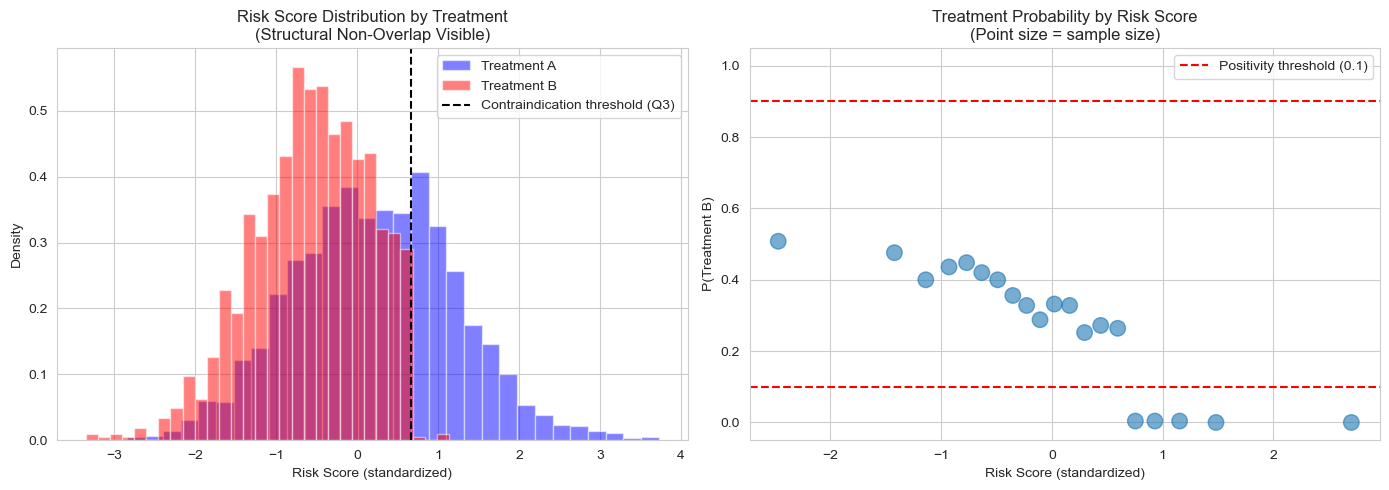


⚠️ FAILURE MODE: Structural Non-Overlap
Treatment B is rarely/never given to high-risk patients.
→ Cannot estimate ATE; can only estimate effect in overlap region.


In [5]:
# Visualize the overlap problem
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Risk score distribution by treatment
axes[0].hist(df[df['treatment']==0]['risk_score'], bins=30, alpha=0.5, 
             label='Treatment A', density=True, color='blue')
axes[0].hist(df[df['treatment']==1]['risk_score'], bins=30, alpha=0.5, 
             label='Treatment B', density=True, color='red')
axes[0].axvline(np.percentile(df['risk_score'], 75), color='black', 
                linestyle='--', label='Contraindication threshold (Q3)')
axes[0].set_xlabel('Risk Score (standardized)')
axes[0].set_ylabel('Density')
axes[0].set_title('Risk Score Distribution by Treatment\n(Structural Non-Overlap Visible)')
axes[0].legend()

# Panel 2: Treatment probability by risk score
risk_bins = pd.qcut(df['risk_score'], q=20, duplicates='drop')
prob_by_risk = df.groupby(risk_bins)['treatment'].agg(['mean', 'count'])
risk_midpoints = [interval.mid for interval in prob_by_risk.index]

axes[1].scatter(risk_midpoints, prob_by_risk['mean'], 
                s=prob_by_risk['count']/2, alpha=0.6)
axes[1].axhline(0.1, color='red', linestyle='--', label='Positivity threshold (0.1)')
axes[1].axhline(0.9, color='red', linestyle='--')
axes[1].set_xlabel('Risk Score (standardized)')
axes[1].set_ylabel('P(Treatment B)')
axes[1].set_title('Treatment Probability by Risk Score\n(Point size = sample size)')
axes[1].legend()
axes[1].set_ylim([-0.05, 1.05])

plt.tight_layout()
plt.show()

print("\n⚠️ FAILURE MODE: Structural Non-Overlap")
print("Treatment B is rarely/never given to high-risk patients.")
print("→ Cannot estimate ATE; can only estimate effect in overlap region.")

### Failure Mode 2: Unmeasured Confounding
Even in overlap region, unmeasured severity biases estimates

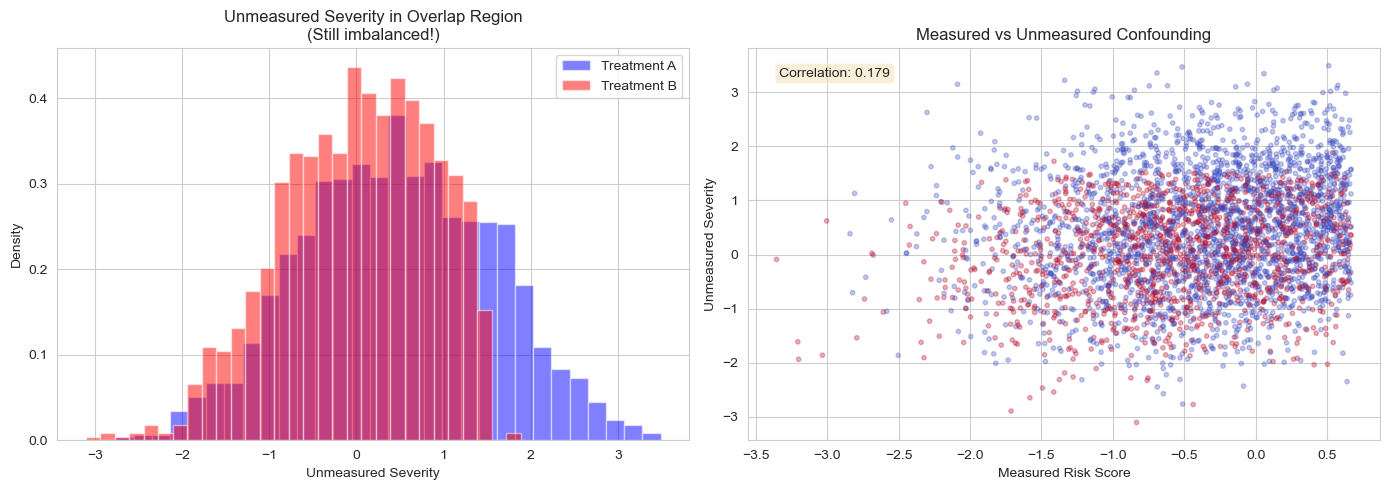


⚠️ FAILURE MODE: Unmeasured Confounding
Even in overlap region, unmeasured severity differs by treatment:
  Treatment A: 0.474
  Treatment B: 0.019
  Difference: -0.455
→ Exchangeability violated even after restricting to overlap.


In [7]:
# Show unmeasured confounding
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Unmeasured severity by treatment (in overlap region)
overlap_region = (df['risk_score'] < np.percentile(df['risk_score'], 75))
df_overlap = df[overlap_region].copy()

axes[0].hist(df_overlap[df_overlap['treatment']==0]['unmeasured_severity'], 
             bins=30, alpha=0.5, label='Treatment A', density=True, color='blue')
axes[0].hist(df_overlap[df_overlap['treatment']==1]['unmeasured_severity'], 
             bins=30, alpha=0.5, label='Treatment B', density=True, color='red')
axes[0].set_xlabel('Unmeasured Severity')
axes[0].set_ylabel('Density')
axes[0].set_title('Unmeasured Severity in Overlap Region\n(Still imbalanced!)')
axes[0].legend()

# Panel 2: Correlation between measured and unmeasured
axes[1].scatter(df_overlap['risk_score'], df_overlap['unmeasured_severity'], 
                c=df_overlap['treatment'], cmap='coolwarm', alpha=0.3, s=10)
axes[1].set_xlabel('Measured Risk Score')
axes[1].set_ylabel('Unmeasured Severity')
axes[1].set_title('Measured vs Unmeasured Confounding')
axes[1].text(0.05, 0.95, f"Correlation: {df_overlap['risk_score'].corr(df_overlap['unmeasured_severity']):.3f}",
             transform=axes[1].transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n⚠️ FAILURE MODE: Unmeasured Confounding")
print(f"Even in overlap region, unmeasured severity differs by treatment:")
print(f"  Treatment A: {df_overlap[df_overlap['treatment']==0]['unmeasured_severity'].mean():.3f}")
print(f"  Treatment B: {df_overlap[df_overlap['treatment']==1]['unmeasured_severity'].mean():.3f}")
print(f"  Difference: {df_overlap[df_overlap['treatment']==1]['unmeasured_severity'].mean() - df_overlap[df_overlap['treatment']==0]['unmeasured_severity'].mean():.3f}")
print("→ Exchangeability violated even after restricting to overlap.")

## 4. Diagnostics

### 4.1 Propensity Score Analysis

In [9]:
# Estimate propensity score using measured covariates only
measured_covs = ['age', 'comorbidity_count', 'prior_hospitalization', 
                 'creatinine', 'hemoglobin']

X = df[measured_covs].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PS model
ps_model = LogisticRegression(random_state=42, max_iter=1000)
ps_model.fit(X_scaled, df['treatment'])
df['ps'] = ps_model.predict_proba(X_scaled)[:, 1]

print("Propensity Score Model Coefficients:")
for cov, coef in zip(measured_covs, ps_model.coef_[0]):
    print(f"  {cov}: {coef:.3f}")

Propensity Score Model Coefficients:
  age: -0.540
  comorbidity_count: -0.573
  prior_hospitalization: -0.328
  creatinine: -0.365
  hemoglobin: 0.355


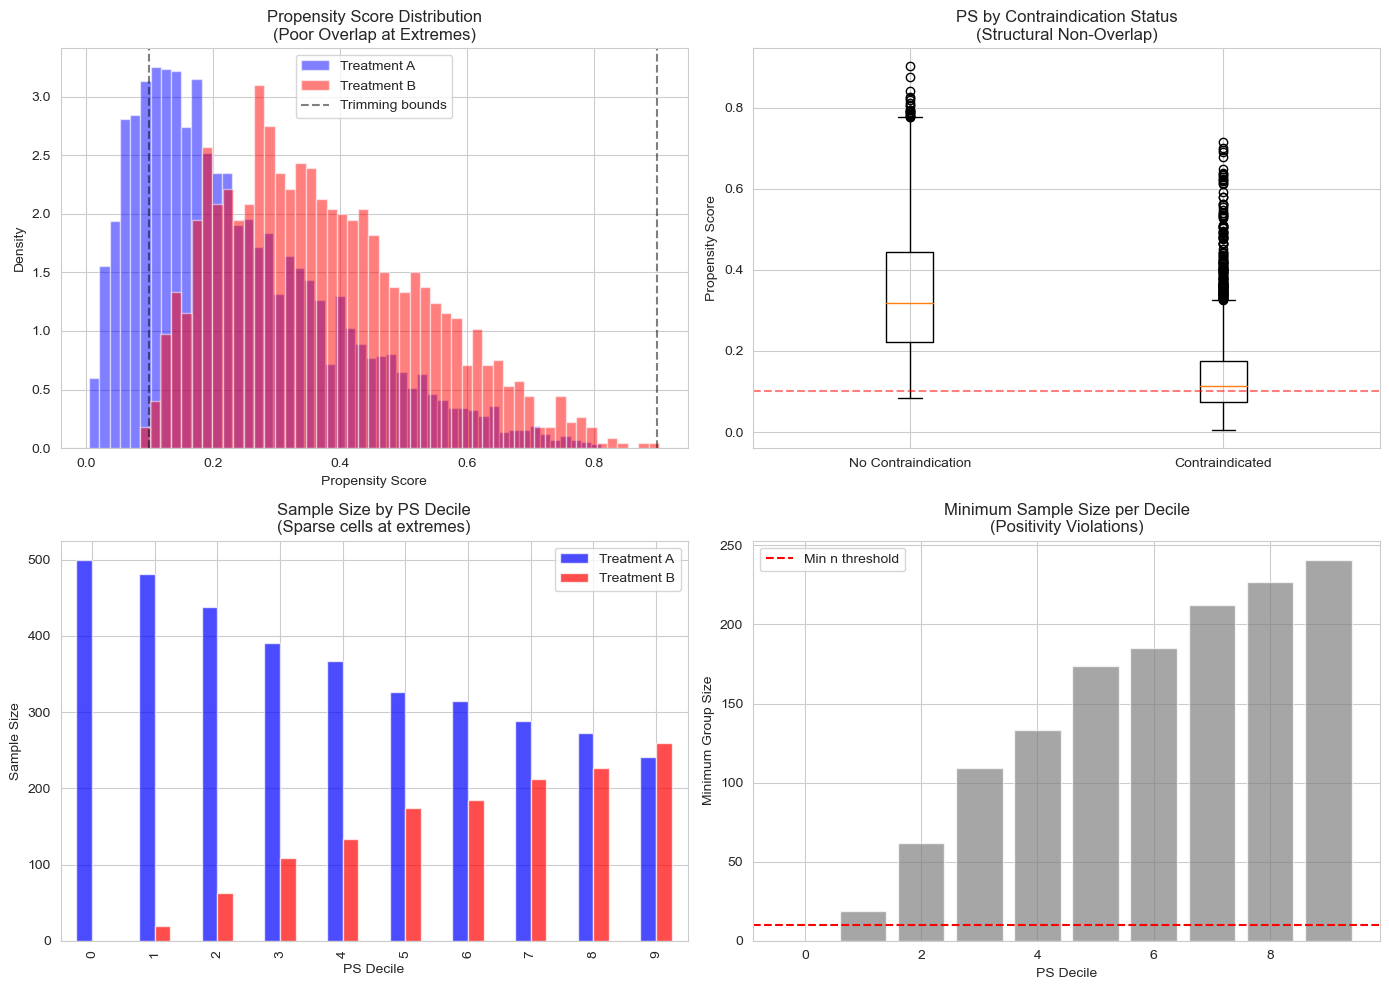


OVERLAP DIAGNOSTICS

PS range - Treatment A: [0.005, 0.812]
PS range - Treatment B: [0.085, 0.903]

Treatment A patients with PS > 0.9: 0
Treatment B patients with PS < 0.1: 4

PS deciles with < 10 patients in either group: 1


In [11]:
# Visualize PS distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: PS distributions by treatment
axes[0, 0].hist(df[df['treatment']==0]['ps'], bins=50, alpha=0.5, 
                label='Treatment A', density=True, color='blue')
axes[0, 0].hist(df[df['treatment']==1]['ps'], bins=50, alpha=0.5, 
                label='Treatment B', density=True, color='red')
axes[0, 0].axvline(0.1, color='black', linestyle='--', alpha=0.5, label='Trimming bounds')
axes[0, 0].axvline(0.9, color='black', linestyle='--', alpha=0.5)
axes[0, 0].set_xlabel('Propensity Score')
axes[0, 0].set_ylabel('Density')
axes[0, 0].set_title('Propensity Score Distribution\n(Poor Overlap at Extremes)')
axes[0, 0].legend()

# Panel 2: PS by contraindication status
axes[0, 1].boxplot([df[df['contraindication']==0]['ps'],
                     df[df['contraindication']==1]['ps']],
                    labels=['No Contraindication', 'Contraindicated'])
axes[0, 1].axhline(0.1, color='red', linestyle='--', alpha=0.5)
axes[0, 1].set_ylabel('Propensity Score')
axes[0, 1].set_title('PS by Contraindication Status\n(Structural Non-Overlap)')

# Panel 3: Sample size by PS decile
df['ps_decile'] = pd.qcut(df['ps'], q=10, labels=False, duplicates='drop')
ps_counts = df.groupby(['ps_decile', 'treatment']).size().unstack(fill_value=0)
ps_counts.plot(kind='bar', ax=axes[1, 0], color=['blue', 'red'], alpha=0.7)
axes[1, 0].set_xlabel('PS Decile')
axes[1, 0].set_ylabel('Sample Size')
axes[1, 0].set_title('Sample Size by PS Decile\n(Sparse cells at extremes)')
axes[1, 0].legend(['Treatment A', 'Treatment B'])

# Panel 4: Minimum sample size per decile
min_n = ps_counts.min(axis=1)
axes[1, 1].bar(range(len(min_n)), min_n, color='gray', alpha=0.7)
axes[1, 1].axhline(10, color='red', linestyle='--', label='Min n threshold')
axes[1, 1].set_xlabel('PS Decile')
axes[1, 1].set_ylabel('Minimum Group Size')
axes[1, 1].set_title('Minimum Sample Size per Decile\n(Positivity Violations)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Quantify overlap issues
print("\n" + "="*60)
print("OVERLAP DIAGNOSTICS")
print("="*60)
print(f"\nPS range - Treatment A: [{df[df['treatment']==0]['ps'].min():.3f}, {df[df['treatment']==0]['ps'].max():.3f}]")
print(f"PS range - Treatment B: [{df[df['treatment']==1]['ps'].min():.3f}, {df[df['treatment']==1]['ps'].max():.3f}]")
print(f"\nTreatment A patients with PS > 0.9: {(df[df['treatment']==0]['ps'] > 0.9).sum()}")
print(f"Treatment B patients with PS < 0.1: {(df[df['treatment']==1]['ps'] < 0.1).sum()}")
print(f"\nPS deciles with < 10 patients in either group: {(min_n < 10).sum()}")

### 4.2 Covariate Balance

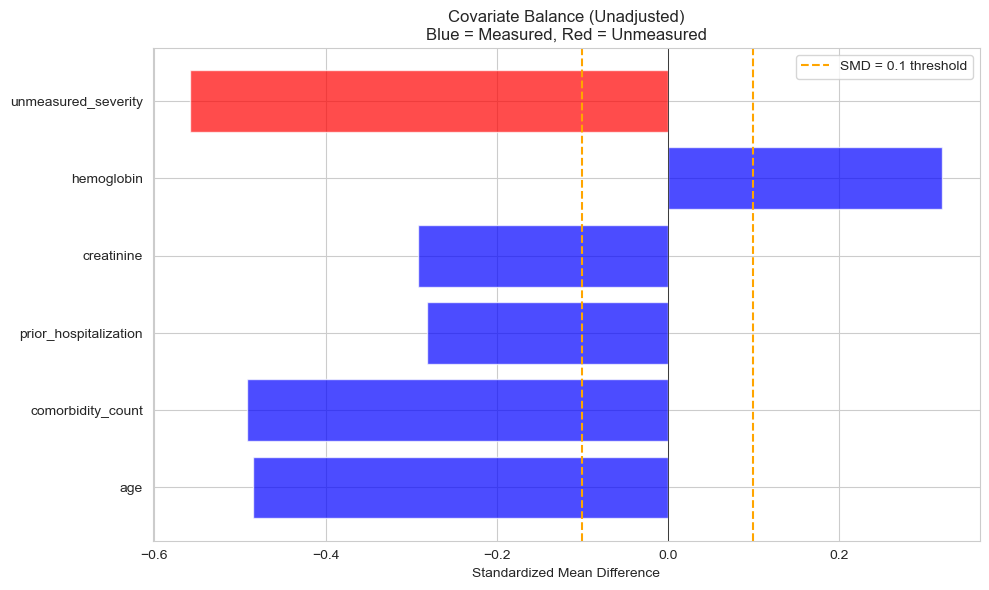


Covariate Balance:
             Variable  SMD_Unweighted        Measured
                  age       -0.485278             Yes
    comorbidity_count       -0.492166             Yes
prior_hospitalization       -0.281482             Yes
           creatinine       -0.292240             Yes
           hemoglobin        0.320955             Yes
  unmeasured_severity       -0.558026 No (UNMEASURED)

⚠️ Unmeasured severity has large imbalance (SMD = -0.558)
→ This imbalance remains even after PS adjustment on measured covariates.


In [13]:
def calculate_smd(treated, control):
    """Calculate standardized mean difference"""
    mean_diff = treated.mean() - control.mean()
    pooled_std = np.sqrt((treated.var() + control.var()) / 2)
    return mean_diff / pooled_std if pooled_std > 0 else 0

# Calculate SMD for measured and unmeasured variables
balance_vars = measured_covs + ['unmeasured_severity']
treated = df[df['treatment']==1]
control = df[df['treatment']==0]

smd_unweighted = []
for var in balance_vars:
    smd = calculate_smd(treated[var], control[var])
    smd_unweighted.append(smd)
    
balance_df = pd.DataFrame({
    'Variable': balance_vars,
    'SMD_Unweighted': smd_unweighted,
    'Measured': ['Yes'] * len(measured_covs) + ['No (UNMEASURED)']
})

# Visualize balance
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['blue' if m == 'Yes' else 'red' for m in balance_df['Measured']]
ax.barh(range(len(balance_df)), balance_df['SMD_Unweighted'], color=colors, alpha=0.7)
ax.axvline(0.1, color='orange', linestyle='--', label='SMD = 0.1 threshold')
ax.axvline(-0.1, color='orange', linestyle='--')
ax.axvline(0, color='black', linestyle='-', linewidth=0.5)
ax.set_yticks(range(len(balance_df)))
ax.set_yticklabels(balance_df['Variable'])
ax.set_xlabel('Standardized Mean Difference')
ax.set_title('Covariate Balance (Unadjusted)\nBlue = Measured, Red = Unmeasured')
ax.legend()
plt.tight_layout()
plt.show()

print("\nCovariate Balance:")
print(balance_df.to_string(index=False))
print("\n⚠️ Unmeasured severity has large imbalance (SMD = {:.3f})".format(
    balance_df[balance_df['Variable']=='unmeasured_severity']['SMD_Unweighted'].values[0]))
print("→ This imbalance remains even after PS adjustment on measured covariates.")

### 4.3 Competing Events Diagnostics

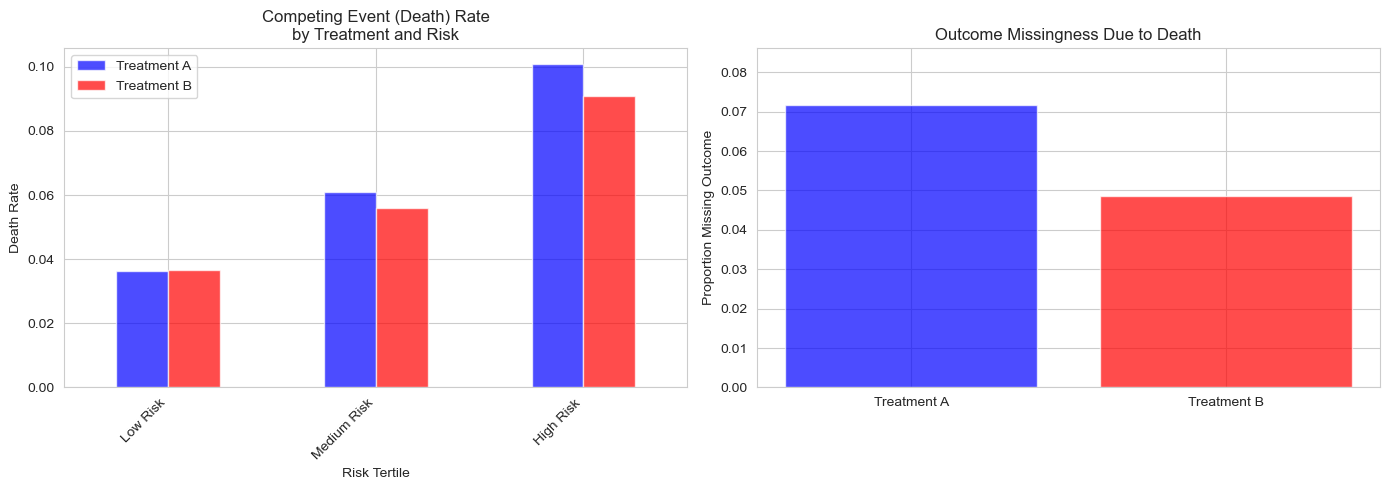


COMPETING EVENTS DIAGNOSTICS

Overall death rate: 6.5%
Death rate - Treatment A: 7.2%
Death rate - Treatment B: 4.9%

Differential death rate: -2.3 percentage points

⚠️ ESTIMAND CHANGE: Competing events alter the risk set.
   Naive analysis (complete case) estimates effect among survivors,
   not the original population → biased estimate.


In [15]:
# Analyze competing events
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Death rate by treatment and risk score
risk_tertiles = pd.qcut(df['risk_score'], q=3, labels=['Low Risk', 'Medium Risk', 'High Risk'])
death_by_risk = df.groupby([risk_tertiles, 'treatment'])['death'].mean().unstack()
death_by_risk.plot(kind='bar', ax=axes[0], color=['blue', 'red'], alpha=0.7)
axes[0].set_xlabel('Risk Tertile')
axes[0].set_ylabel('Death Rate')
axes[0].set_title('Competing Event (Death) Rate\nby Treatment and Risk')
axes[0].legend(['Treatment A', 'Treatment B'])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Panel 2: Outcome missingness
missing_by_trt = df.groupby('treatment')['hospitalization'].apply(lambda x: x.isna().mean())
axes[1].bar([0, 1], missing_by_trt, color=['blue', 'red'], alpha=0.7)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Treatment A', 'Treatment B'])
axes[1].set_ylabel('Proportion Missing Outcome')
axes[1].set_title('Outcome Missingness Due to Death')
axes[1].set_ylim([0, max(missing_by_trt) * 1.2])

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("COMPETING EVENTS DIAGNOSTICS")
print("="*60)
print(f"\nOverall death rate: {df['death'].mean()*100:.1f}%")
print(f"Death rate - Treatment A: {df[df['treatment']==0]['death'].mean()*100:.1f}%")
print(f"Death rate - Treatment B: {df[df['treatment']==1]['death'].mean()*100:.1f}%")
print(f"\nDifferential death rate: {(df[df['treatment']==1]['death'].mean() - df[df['treatment']==0]['death'].mean())*100:.1f} percentage points")
print(f"\n⚠️ ESTIMAND CHANGE: Competing events alter the risk set.")
print(f"   Naive analysis (complete case) estimates effect among survivors,")
print(f"   not the original population → biased estimate.")

## 5. Weighting Schemes and Trimming

### 5.1 Inverse Probability of Treatment Weighting (IPTW)

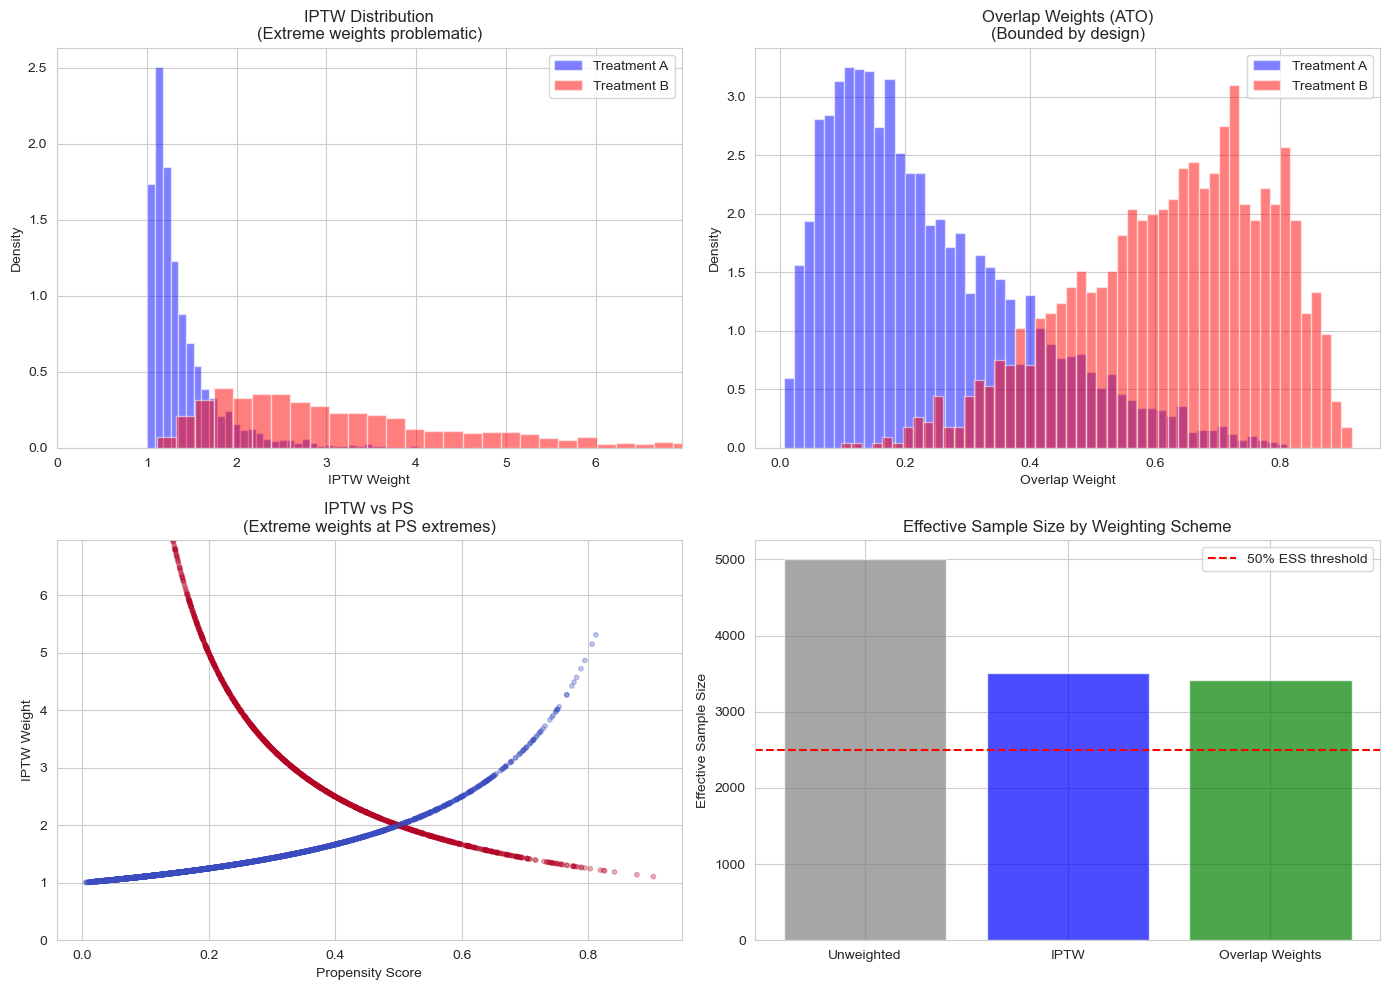


WEIGHTING DIAGNOSTICS

IPTW:
  Max weight: 11.8
  % weights > 10: 0.1%
  Effective sample size: 3510 (70.2% of original)

Overlap Weights:
  Max weight: 0.9
  Effective sample size: 3418 (68.4% of original)


In [17]:
# Calculate IPTW weights
df['iptw'] = np.where(df['treatment']==1, 
                       1/df['ps'], 
                       1/(1-df['ps']))

# Calculate overlap weights (ATO)
df['overlap_weight'] = np.where(df['treatment']==1,
                                 1 - df['ps'],
                                 df['ps'])

# Visualize weights
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: IPTW distribution
axes[0, 0].hist(df[df['treatment']==0]['iptw'], bins=50, alpha=0.5, 
                label='Treatment A', density=True, color='blue')
axes[0, 0].hist(df[df['treatment']==1]['iptw'], bins=50, alpha=0.5, 
                label='Treatment B', density=True, color='red')
axes[0, 0].set_xlabel('IPTW Weight')
axes[0, 0].set_ylabel('Density')
axes[0, 0].set_title('IPTW Distribution\n(Extreme weights problematic)')
axes[0, 0].legend()
axes[0, 0].set_xlim([0, min(100, df['iptw'].quantile(0.99))])

# Panel 2: Overlap weights distribution  
axes[0, 1].hist(df[df['treatment']==0]['overlap_weight'], bins=50, alpha=0.5, 
                label='Treatment A', density=True, color='blue')
axes[0, 1].hist(df[df['treatment']==1]['overlap_weight'], bins=50, alpha=0.5, 
                label='Treatment B', density=True, color='red')
axes[0, 1].set_xlabel('Overlap Weight')
axes[0, 1].set_ylabel('Density')
axes[0, 1].set_title('Overlap Weights (ATO)\n(Bounded by design)')
axes[0, 1].legend()

# Panel 3: IPTW by PS
axes[1, 0].scatter(df['ps'], df['iptw'], alpha=0.3, s=10, c=df['treatment'], cmap='coolwarm')
axes[1, 0].set_xlabel('Propensity Score')
axes[1, 0].set_ylabel('IPTW Weight')
axes[1, 0].set_title('IPTW vs PS\n(Extreme weights at PS extremes)')
axes[1, 0].set_ylim([0, min(100, df['iptw'].quantile(0.99))])

# Panel 4: Effective sample size
ess_iptw = (df['iptw'].sum())**2 / (df['iptw']**2).sum()
ess_overlap = (df['overlap_weight'].sum())**2 / (df['overlap_weight']**2).sum()

axes[1, 1].bar(['Unweighted', 'IPTW', 'Overlap Weights'], 
               [len(df), ess_iptw, ess_overlap],
               color=['gray', 'blue', 'green'], alpha=0.7)
axes[1, 1].set_ylabel('Effective Sample Size')
axes[1, 1].set_title('Effective Sample Size by Weighting Scheme')
axes[1, 1].axhline(len(df)*0.5, color='red', linestyle='--', label='50% ESS threshold')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("WEIGHTING DIAGNOSTICS")
print("="*60)
print("\nIPTW:")
print(f"  Max weight: {df['iptw'].max():.1f}")
print(f"  % weights > 10: {(df['iptw'] > 10).mean()*100:.1f}%")
print(f"  Effective sample size: {ess_iptw:.0f} ({ess_iptw/len(df)*100:.1f}% of original)")
print("\nOverlap Weights:")
print(f"  Max weight: {df['overlap_weight'].max():.1f}")
print(f"  Effective sample size: {ess_overlap:.0f} ({ess_overlap/len(df)*100:.1f}% of original)")

### 5.2 Trimming Strategies

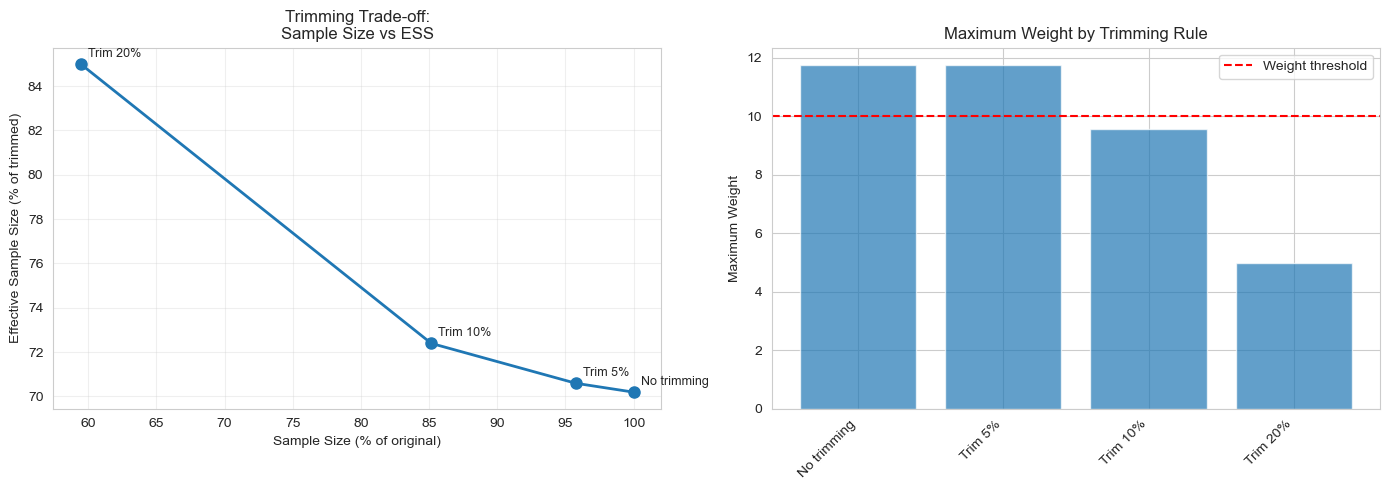


TRIMMING SENSITIVITY
       Rule    N  N_pct  Max_weight         ESS   ESS_pct
No trimming 5000 100.00   11.761957 3509.654151 70.193083
    Trim 5% 4788  95.76   11.761957 3380.027780 70.593730
   Trim 10% 4258  85.16    9.564982 3082.507089 72.393309
   Trim 20% 2973  59.46    4.993430 2526.708733 84.988521


In [19]:
# Apply trimming rules
def apply_trimming(df, ps_col='ps', lower=0.1, upper=0.9):
    """Trim observations with extreme PS values"""
    df_trimmed = df[(df[ps_col] >= lower) & (df[ps_col] <= upper)].copy()
    return df_trimmed

# Different trimming thresholds
trimming_rules = [
    (0.0, 1.0, 'No trimming'),
    (0.05, 0.95, 'Trim 5%'),
    (0.1, 0.9, 'Trim 10%'),
    (0.2, 0.8, 'Trim 20%')
]

trimming_results = []
for lower, upper, label in trimming_rules:
    df_trim = apply_trimming(df, lower=lower, upper=upper)
    
    # Recalculate IPTW
    df_trim['iptw_trimmed'] = np.where(df_trim['treatment']==1,
                                        1/df_trim['ps'],
                                        1/(1-df_trim['ps']))
    
    ess = (df_trim['iptw_trimmed'].sum())**2 / (df_trim['iptw_trimmed']**2).sum()
    max_weight = df_trim['iptw_trimmed'].max()
    
    trimming_results.append({
        'Rule': label,
        'N': len(df_trim),
        'N_pct': len(df_trim)/len(df)*100,
        'Max_weight': max_weight,
        'ESS': ess,
        'ESS_pct': ess/len(df_trim)*100
    })

trimming_df = pd.DataFrame(trimming_results)

# Visualize trimming trade-offs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Sample size vs ESS
axes[0].plot(trimming_df['N_pct'], trimming_df['ESS_pct'], 
             marker='o', markersize=8, linewidth=2)
for i, row in trimming_df.iterrows():
    axes[0].annotate(row['Rule'], 
                     (row['N_pct'], row['ESS_pct']),
                     xytext=(5, 5), textcoords='offset points', fontsize=9)
axes[0].set_xlabel('Sample Size (% of original)')
axes[0].set_ylabel('Effective Sample Size (% of trimmed)')
axes[0].set_title('Trimming Trade-off:\nSample Size vs ESS')
axes[0].grid(True, alpha=0.3)

# Panel 2: Max weight reduction
axes[1].bar(range(len(trimming_df)), trimming_df['Max_weight'], alpha=0.7)
axes[1].set_xticks(range(len(trimming_df)))
axes[1].set_xticklabels(trimming_df['Rule'], rotation=45, ha='right')
axes[1].set_ylabel('Maximum Weight')
axes[1].set_title('Maximum Weight by Trimming Rule')
axes[1].axhline(10, color='red', linestyle='--', label='Weight threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("TRIMMING SENSITIVITY")
print("="*60)
print(trimming_df.to_string(index=False))

## 6. Estimand Definition and Decision Rules

### Critical Decision Point: Is the ATE Identifiable?

In [21]:
# DECISION RULE IMPLEMENTATION
def evaluate_identifiability(df, ps_col='ps', 
                             max_weight_threshold=10,
                             ess_threshold_pct=50,
                             min_group_size=10,
                             ps_trim_lower=0.1,
                             ps_trim_upper=0.9):
    """
    Evaluate whether ATE is identifiable and recommend estimand.
    
    Returns:
        decision: 'ATE', 'ATT', 'ATO', or 'STOP'
        reasons: list of diagnostic findings
        df_analysis: recommended analysis dataset
    """
    
    reasons = []
    decision = 'ATE'  # Start optimistic
    
    # Check 1: Positivity violations
    n_ps_too_low = ((df[df['treatment']==1][ps_col] < ps_trim_lower).sum())
    n_ps_too_high = ((df[df['treatment']==0][ps_col] > ps_trim_upper).sum())
    
    if n_ps_too_low > 0 or n_ps_too_high > 0:
        reasons.append(f"Positivity violation: {n_ps_too_low} treated with PS<{ps_trim_lower}, "
                      f"{n_ps_too_high} control with PS>{ps_trim_upper}")
        decision = 'ATO'  # Downgrade to overlap population
    
    # Check 2: Extreme weights
    df['iptw_check'] = np.where(df['treatment']==1, 1/df[ps_col], 1/(1-df[ps_col]))
    max_weight = df['iptw_check'].max()
    pct_extreme = (df['iptw_check'] > max_weight_threshold).mean() * 100
    
    if max_weight > max_weight_threshold:
        reasons.append(f"Extreme weights: max={max_weight:.1f}, "
                      f"{pct_extreme:.1f}% > {max_weight_threshold}")
        if decision == 'ATE':
            decision = 'ATO'
    
    # Check 3: Effective sample size
    ess = (df['iptw_check'].sum())**2 / (df['iptw_check']**2).sum()
    ess_pct = ess / len(df) * 100
    
    if ess_pct < ess_threshold_pct:
        reasons.append(f"Low ESS: {ess:.0f} ({ess_pct:.1f}% of N) < {ess_threshold_pct}%")
        if decision == 'ATE':
            decision = 'ATO'
    
    # Check 4: Sparse cells
    df['ps_decile'] = pd.qcut(df[ps_col], q=10, labels=False, duplicates='drop')
    ps_counts = df.groupby(['ps_decile', 'treatment']).size().unstack(fill_value=0)
    min_cell_size = ps_counts.min().min()
    n_sparse = (ps_counts.min(axis=1) < min_group_size).sum()
    
    if n_sparse > 0:
        reasons.append(f"Sparse cells: {n_sparse} PS deciles with min n < {min_group_size}")
        if decision == 'ATE':
            decision = 'ATO'
    
    # Check 5: After trimming, is ATO feasible?
    if decision == 'ATO':
        df_trimmed = df[(df[ps_col] >= ps_trim_lower) & (df[ps_col] <= ps_trim_upper)].copy()
        
        if len(df_trimmed) < 0.5 * len(df):
            reasons.append(f"Severe trimming: {len(df_trimmed)} ({len(df_trimmed)/len(df)*100:.1f}%) remaining")
            decision = 'STOP'
        
        # Recalculate ESS for overlap weights
        df_trimmed['overlap_w'] = np.where(df_trimmed['treatment']==1,
                                            1 - df_trimmed[ps_col],
                                            df_trimmed[ps_col])
        ess_overlap = (df_trimmed['overlap_w'].sum())**2 / (df_trimmed['overlap_w']**2).sum()
        
        if ess_overlap < 0.3 * len(df_trimmed):
            reasons.append(f"Low overlap ESS: {ess_overlap:.0f} even after trimming")
            decision = 'STOP'
    
    # Prepare analysis dataset
    if decision == 'ATO':
        df_analysis = df[(df[ps_col] >= ps_trim_lower) & (df[ps_col] <= ps_trim_upper)].copy()
    elif decision == 'STOP':
        df_analysis = None
    else:
        df_analysis = df.copy()
    
    return decision, reasons, df_analysis

# Apply decision rule
decision, reasons, df_analysis = evaluate_identifiability(df)

print("\n" + "="*60)
print("IDENTIFIABILITY DECISION RULE")
print("="*60)
print(f"\nDECISION: {decision}")
print("\nREASONS:")
for i, reason in enumerate(reasons, 1):
    print(f"  {i}. {reason}")

if decision == 'STOP':
    print("\n" + ""*60)
    print("⛔ ANALYSIS SHOULD NOT PROCEED")
    print(""*60)
    print("\nThe causal contrast is not identifiable from this data.")
    print("Recommendations:")
    print("  1. Do not report any causal estimate")
    print("  2. Report diagnostic findings transparently")
    print("  3. Consider alternative study designs or data sources")
    print("  4. Acknowledge structural limitations in discussion")
    
elif decision == 'ATO':
    print("\n" + "⚠️"*30)
    print("ESTIMAND CHANGED: ATO (Overlap Population)")
    print("⚠️"*30)
    print(f"\nOriginal N: {len(df)}")
    print(f"Overlap N: {len(df_analysis)}")
    print(f"Excluded: {len(df) - len(df_analysis)} ({(len(df)-len(df_analysis))/len(df)*100:.1f}%)")
    print("\nREPORTING LANGUAGE:")
    print('  "We estimated the average treatment effect in the overlap population"')
    print('  "(patients with propensity scores between 0.1 and 0.9) using overlap"')
    print('  "weighting. This estimand represents the effect in patients for whom"')
    print('  "treatment choice was most uncertain, excluding those with strong"')
    print('  "clinical contraindications or indications."')
    
else:
    print("\n✓ ATE appears identifiable (proceed with caution)")
    print("\nNote: Exchangeability still requires assumption of no unmeasured confounding.")


IDENTIFIABILITY DECISION RULE

DECISION: ATO

REASONS:
  1. Positivity violation: 4 treated with PS<0.1, 0 control with PS>0.9
  2. Extreme weights: max=11.8, 0.1% > 10
  3. Sparse cells: 1 PS deciles with min n < 10

⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️
ESTIMAND CHANGED: ATO (Overlap Population)
⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️

Original N: 5000
Overlap N: 4258
Excluded: 742 (14.8%)

REPORTING LANGUAGE:
  "We estimated the average treatment effect in the overlap population"
  "(patients with propensity scores between 0.1 and 0.9) using overlap"
  "weighting. This estimand represents the effect in patients for whom"
  "treatment choice was most uncertain, excluding those with strong"
  "clinical contraindications or indications."


## 7. Mitigation Approaches (With Limits)

### 7.1 Proxy Adjustment for Unmeasured Confounding

In [23]:
# Demonstrate that proxy adjustment reduces but doesn't eliminate bias
print("\n" + "="*60)
print("PROXY ADJUSTMENT DEMONSTRATION")
print("="*60)

# Only proceed if we have an analysis dataset
if df_analysis is not None:
    
    # Calculate outcomes (using complete cases)
    df_complete = df_analysis[df_analysis['hospitalization'].notna()].copy()
    
    # Naive estimate (no adjustment)
    ate_naive = (df_complete[df_complete['treatment']==1]['hospitalization'].mean() - 
                 df_complete[df_complete['treatment']==0]['hospitalization'].mean())
    
    # Proxy-adjusted estimate (using measured covariates)
    # Re-estimate PS on analysis dataset
    X_analysis = df_complete[measured_covs].copy()
    X_analysis_scaled = scaler.fit_transform(X_analysis)
    ps_model_analysis = LogisticRegression(random_state=42, max_iter=1000)
    ps_model_analysis.fit(X_analysis_scaled, df_complete['treatment'])
    df_complete['ps_analysis'] = ps_model_analysis.predict_proba(X_analysis_scaled)[:, 1]
    
    # Calculate overlap weights
    df_complete['ow'] = np.where(df_complete['treatment']==1,
                                  1 - df_complete['ps_analysis'],
                                  df_complete['ps_analysis'])
    
    # Weighted means
    treated = df_complete[df_complete['treatment']==1]
    control = df_complete[df_complete['treatment']==0]
    
    y1_weighted = np.average(treated['hospitalization'], weights=treated['ow'])
    y0_weighted = np.average(control['hospitalization'], weights=control['ow'])
    ate_weighted = y1_weighted - y0_weighted
    
    # TRUE effect (using unmeasured severity - oracle)
    # Estimate what we'd get with perfect adjustment
    all_covs = measured_covs + ['unmeasured_severity']
    X_oracle = df_complete[all_covs].copy()
    X_oracle_scaled = StandardScaler().fit_transform(X_oracle)
    ps_oracle = LogisticRegression(random_state=42, max_iter=1000)
    ps_oracle.fit(X_oracle_scaled, df_complete['treatment'])
    df_complete['ps_oracle'] = ps_oracle.predict_proba(X_oracle_scaled)[:, 1]
    
    df_complete['ow_oracle'] = np.where(df_complete['treatment']==1,
                                        1 - df_complete['ps_oracle'],
                                        df_complete['ps_oracle'])
    
    treated_o = df_complete[df_complete['treatment']==1]
    control_o = df_complete[df_complete['treatment']==0]
    
    y1_oracle = np.average(treated_o['hospitalization'], weights=treated_o['ow_oracle'])
    y0_oracle = np.average(control_o['hospitalization'], weights=control_o['ow_oracle'])
    ate_oracle = y1_oracle - y0_oracle
    
    # True average treatment effect in this population
    ate_true = df_complete['true_treatment_effect'].mean()
    
    print("\nEstimates (Risk Difference):")
    print(f"  Naive (unadjusted):        {ate_naive:.4f}")
    print(f"  Proxy-adjusted (measured): {ate_weighted:.4f}")
    print(f"  Oracle (with unmeasured):  {ate_oracle:.4f}")
    print(f"  Truth (simulation):        {ate_true:.4f}")
    
    print("\nBias:")
    print(f"  Naive bias:          {ate_naive - ate_true:.4f}")
    print(f"  Proxy-adjusted bias: {ate_weighted - ate_true:.4f}")
    print(f"  Oracle bias:         {ate_oracle - ate_true:.4f}")
    
    print("\n" + "⚠️"*30)
    print("KEY INSIGHT: Proxy adjustment reduces but does NOT eliminate bias")
    print("⚠️"*30)
    print("\nResidual confounding remains due to unmeasured severity.")
    print("No amount of proxy adjustment can fully substitute for unmeasured U.")
    
else:
    print("\nAnalysis stopped - no valid estimand available.")


PROXY ADJUSTMENT DEMONSTRATION

Estimates (Risk Difference):
  Naive (unadjusted):        -0.0980
  Proxy-adjusted (measured): -0.0582
  Oracle (with unmeasured):  -0.0279
  Truth (simulation):        -0.1353

Bias:
  Naive bias:          0.0372
  Proxy-adjusted bias: 0.0771
  Oracle bias:         0.1073

⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️
KEY INSIGHT: Proxy adjustment reduces but does NOT eliminate bias
⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️

Residual confounding remains due to unmeasured severity.
No amount of proxy adjustment can fully substitute for unmeasured U.


### 7.2 Quantitative Bias Analysis (E-value)

In [25]:
def calculate_evalue(rr, ci_lower=None):
    """
    Calculate E-value for unmeasured confounding.
    
    E-value: minimum strength of association (RR scale) that an unmeasured 
    confounder would need to have with both treatment and outcome to explain 
    away the observed effect.
    """
    if rr < 1:
        rr = 1 / rr
    
    evalue = rr + np.sqrt(rr * (rr - 1))
    
    if ci_lower is not None:
        if ci_lower < 1:
            ci_lower = 1 / ci_lower
        evalue_ci = ci_lower + np.sqrt(ci_lower * (ci_lower - 1))
        return evalue, evalue_ci
    
    return evalue

if df_analysis is not None and df_complete is not None:
    # Convert risk difference to RR for E-value
    risk_treated = df_complete[df_complete['treatment']==1]['hospitalization'].mean()
    risk_control = df_complete[df_complete['treatment']==0]['hospitalization'].mean()
    rr_naive = risk_treated / risk_control
    
    # Simple bootstrap CI (for illustration)
    n_boot = 1000
    rr_boot = []
    for _ in range(n_boot):
        boot_sample = df_complete.sample(n=len(df_complete), replace=True)
        r1 = boot_sample[boot_sample['treatment']==1]['hospitalization'].mean()
        r0 = boot_sample[boot_sample['treatment']==0]['hospitalization'].mean()
        rr_boot.append(r1 / r0)
    
    rr_ci_lower = np.percentile(rr_boot, 2.5)
    rr_ci_upper = np.percentile(rr_boot, 97.5)
    
    evalue, evalue_ci = calculate_evalue(rr_naive, rr_ci_lower)
    
    print("\n" + "="*60)
    print("QUANTITATIVE BIAS ANALYSIS (E-VALUE)")
    print("="*60)
    print(f"\nObserved RR: {rr_naive:.3f} (95% CI: {rr_ci_lower:.3f}, {rr_ci_upper:.3f})")
    print(f"\nE-value (point estimate): {evalue:.2f}")
    print(f"E-value (CI bound):       {evalue_ci:.2f}")
    
    print("\nInterpretation:")
    print(f"  An unmeasured confounder would need to be associated with both")
    print(f"  treatment and outcome by a risk ratio of {evalue:.2f}-fold to fully")
    print(f"  explain away the observed effect.")
    
    print("\n  For the CI bound, a confounder with RR = {:.2f} could shift the".format(evalue_ci))
    print("  confidence interval to include the null.")
    
    print("\n⚠️ Limitation: E-value is a sensitivity analysis, not a solution.")
    print("   It quantifies but does not eliminate unmeasured confounding.")


QUANTITATIVE BIAS ANALYSIS (E-VALUE)

Observed RR: 0.605 (95% CI: 0.519, 0.700)

E-value (point estimate): 2.69
E-value (CI bound):       3.27

Interpretation:
  An unmeasured confounder would need to be associated with both
  treatment and outcome by a risk ratio of 2.69-fold to fully
  explain away the observed effect.

  For the CI bound, a confounder with RR = 3.27 could shift the
  confidence interval to include the null.

⚠️ Limitation: E-value is a sensitivity analysis, not a solution.
   It quantifies but does not eliminate unmeasured confounding.


### 7.3 Negative Control Outcomes (Diagnostic)

In [27]:
# Simulate a negative control outcome
# (outcome that should NOT be affected by treatment, but shares confounders)
np.random.seed(43)

# Negative control: prior-year hospitalization (pre-treatment)
# Should be associated with confounders but NOT caused by treatment
logit_nc = (
    -2.0 +
    0.5 * df_complete['unmeasured_severity'] +
    0.3 * df_complete['risk_score'] +
    # NO treatment effect
    0.02 * (df_complete['age'] - 65) / 12
)
prob_nc = 1 / (1 + np.exp(-logit_nc))
df_complete['negative_control'] = np.random.binomial(1, prob_nc)

# Estimate effect on negative control
nc_treated = df_complete[df_complete['treatment']==1]['negative_control'].mean()
nc_control = df_complete[df_complete['treatment']==0]['negative_control'].mean()
nc_rd_naive = nc_treated - nc_control

# With overlap weighting
nc_treated_w = np.average(
    df_complete[df_complete['treatment']==1]['negative_control'],
    weights=df_complete[df_complete['treatment']==1]['ow']
)
nc_control_w = np.average(
    df_complete[df_complete['treatment']==0]['negative_control'],
    weights=df_complete[df_complete['treatment']==0]['ow']
)
nc_rd_weighted = nc_treated_w - nc_control_w

print("\n" + "="*60)
print("NEGATIVE CONTROL ANALYSIS")
print("="*60)
print("\nNegative control outcome: Prior-year hospitalization")
print("(Should NOT be affected by current treatment)\n")

print("Effect on negative control:")
print(f"  Naive (unadjusted):  {nc_rd_naive:.4f}")
print(f"  Weighted (adjusted): {nc_rd_weighted:.4f}")
print(f"  Expected (truth):    0.0000")

print("\nInterpretation:")
if abs(nc_rd_naive) > 0.02:
    print("  ⚠️ Non-zero effect on negative control suggests residual confounding.")
    print("     Measured covariates do not fully capture confounders.")
else:
    print("  ✓ Small effect on negative control (encouraging, but not conclusive).")

if abs(nc_rd_weighted) > 0.01:
    print("\n  ⚠️ Weighted estimate still non-zero → unmeasured confounding likely.")
else:
    print("\n  ✓ Weighted estimate near zero (good balance on measured confounders).")

print("\n⚠️ Limitation: Negative controls are diagnostic, not corrective.")
print("   They reveal but do not fix unmeasured confounding.")


NEGATIVE CONTROL ANALYSIS

Negative control outcome: Prior-year hospitalization
(Should NOT be affected by current treatment)

Effect on negative control:
  Naive (unadjusted):  -0.0498
  Weighted (adjusted): -0.0245
  Expected (truth):    0.0000

Interpretation:
  ⚠️ Non-zero effect on negative control suggests residual confounding.
     Measured covariates do not fully capture confounders.

  ⚠️ Weighted estimate still non-zero → unmeasured confounding likely.

⚠️ Limitation: Negative controls are diagnostic, not corrective.
   They reveal but do not fix unmeasured confounding.


## 8. Summary: Decision Rules and Reporting

### Decision Framework

In [29]:
print("\n" + "="*60)
print("DECISION FRAMEWORK SUMMARY")
print("="*60)

framework = """
STEP 1: Assess Overlap (Positivity)
  ├─ Calculate propensity scores
  ├─ Check PS distributions by treatment
  ├─ Examine PS extremes (<0.1, >0.9)
  └─ Decision:
      ├─ Good overlap → Proceed to Step 2
      ├─ Moderate violations → Consider ATO/ATT estimand
      └─ Severe violations → STOP (not identifiable)

STEP 2: Evaluate Weighting
  ├─ Calculate IPTW weights
  ├─ Check max weight (threshold: 10)
  ├─ Calculate ESS (threshold: >50% of N)
  └─ Decision:
      ├─ Stable weights → Proceed with IPTW or ATE
      ├─ Extreme weights → Use overlap weights (ATO)
      └─ Low ESS even with OW → STOP

STEP 3: Check Competing Events
  ├─ Calculate death/censoring rates by treatment
  ├─ Assess differential censoring
  └─ Decision:
      ├─ Low rates (<5%), balanced → Proceed (with caveats)
      ├─ Moderate rates, imbalanced → Acknowledge estimand change
      └─ High rates (>20%), differential → Consider composite/survival analysis

STEP 4: Sensitivity to Unmeasured Confounding
  ├─ Check proxy balance (measured covariates)
  ├─ Negative control analysis
  ├─ E-value calculation
  └─ Decision:
      ├─ Reassuring signals → Report with caveats
      ├─ Concerning signals → Extensive sensitivity analysis
      └─ Strong evidence of bias → Report but emphasize limitations

STEP 5: Final Estimand Statement
  ├─ ATE: "Average effect in full population" (requires strong assumptions)
  ├─ ATO: "Average effect in overlap population" (requires trimming)
  ├─ ATT: "Average effect in treated" (asymmetric assumptions)
  └─ STOP: "Effect not identifiable from this data"
"""

print(framework)

print("\n" + "="*60)
print("REPORTING CHECKLIST")
print("="*60)

checklist = """
Essential Elements:

□ 1. Explicit estimand definition
     "We estimated the [ATE/ATO/ATT] using [method]."

□ 2. Population restriction (if applicable)
     "Analysis restricted to patients with PS between X and Y,
      representing Z% of the original cohort."

□ 3. Overlap diagnostics
     - PS distributions by treatment
     - Weight diagnostics (max, ESS)
     - Sample size in analysis population

□ 4. Unmeasured confounding discussion
     - Which confounders may be unmeasured
     - Direction of expected bias
     - Sensitivity analyses (E-value, negative controls)

□ 5. Competing events handling
     - Frequency of competing events
     - How they affect estimand
     - Analysis approach (complete case, composite, etc.)

□ 6. Limitations section
     "Despite adjustment for measured confounders, residual
      confounding from [specific unmeasured factors] may persist."

□ 7. Avoid causal language if identifiability is questionable
     Use: "associated with" not "caused"
     Use: "adjusted association" not "causal effect"
"""

print(checklist)


DECISION FRAMEWORK SUMMARY

STEP 1: Assess Overlap (Positivity)
  ├─ Calculate propensity scores
  ├─ Check PS distributions by treatment
  ├─ Examine PS extremes (<0.1, >0.9)
  └─ Decision:
      ├─ Good overlap → Proceed to Step 2
      ├─ Moderate violations → Consider ATO/ATT estimand
      └─ Severe violations → STOP (not identifiable)

STEP 2: Evaluate Weighting
  ├─ Calculate IPTW weights
  ├─ Check max weight (threshold: 10)
  ├─ Calculate ESS (threshold: >50% of N)
  └─ Decision:
      ├─ Stable weights → Proceed with IPTW or ATE
      ├─ Extreme weights → Use overlap weights (ATO)
      └─ Low ESS even with OW → STOP

STEP 3: Check Competing Events
  ├─ Calculate death/censoring rates by treatment
  ├─ Assess differential censoring
  └─ Decision:
      ├─ Low rates (<5%), balanced → Proceed (with caveats)
      ├─ Moderate rates, imbalanced → Acknowledge estimand change
      └─ High rates (>20%), differential → Consider composite/survival analysis

STEP 4: Sensitivity to Un

## Key Takeaways

### What We Learned:

1. **Identifiability requires both exchangeability AND positivity**
   - Unmeasured confounding violates exchangeability
   - Structural non-overlap violates positivity
   - Both must hold for the target estimand

2. **EHR data commonly violates these assumptions**
   - Contraindications create structural non-overlap
   - Severity, SDOH, preferences are often unmeasured
   - Competing events change the estimand

3. **Diagnostics can reveal but not fix violations**
   - PS distributions show overlap problems
   - Negative controls reveal unmeasured confounding
   - E-values quantify required bias strength

4. **Mitigation strategies have limits**
   - Proxy adjustment reduces but doesn't eliminate bias
   - Trimming changes the estimand (not a failure!)
   - Overlap weights target a different population

5. **Honesty about estimands is critical**
   - State what you can and cannot estimate
   - Redefine estimand to match overlap region
   - Stop if no valid estimand exists

### Rules of Thumb:

- **Max IPTW weight > 10** → Consider overlap weights
- **ESS < 50% of N** → Reconsider estimand
- **PS extremes with <10 patients** → Trim or stop
- **Negative control RD > 0.05** → Residual confounding likely
- **>50% trimmed** → Estimand too narrow, consider stopping

### Bottom Line:

**The goal is not to force an answer, but to transparently report what can be learned from the data given its limitations.**